# Laboratorio: Minería de Datos — Regresión Lineal Múltiple
**Metodología:** CRISP-DM  
**Modelo:** `sklearn.linear_model.LinearRegression`  
**Ejercicio:** Predicción del Precio del Dólar

In [23]:
# ─────────────────────────────────────────────
# IMPORTS GLOBALES
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Estilo global de gráficas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

---
# EJERCICIO 1 — Predicción del Precio del Dólar
**Dataset:** `dolar_data.csv`  
**Variable dependiente:** `Precio_Dolar`  
**Predictores:** `Dia`, `Inflacion`, `Tasa_interes`

## Fase 1 — Business Understanding
Se busca predecir el precio del dólar a partir de indicadores macroeconómicos diarios.
Esto permite anticipar movimientos cambiarios usando únicamente variables fácilmente observables.

In [24]:
# ─────────────────────────────────────────────
# Fase 2 — DATA UNDERSTANDING
# Carga y exploración inicial del dataset
# ─────────────────────────────────────────────
df_dolar = pd.read_csv('dolar_data.csv')

print('Shape:', df_dolar.shape)
print('\nPrimeras filas:')
display(df_dolar.head())

print('\nEstadísticas descriptivas:')
display(df_dolar.describe())

print('\nValores nulos por columna:')
print(df_dolar.isnull().sum())

Shape: (500, 4)

Primeras filas:


,Dia,Inflacion,Tasa_interes,Precio_Dolar
0,1,0.022484,5.463089,4024.833598
1,2,0.019309,5.954708,4000.546337
2,3,0.023238,4.300716,3979.622045
3,4,0.027615,5.281485,3940.361345
4,5,0.018829,4.674679,4016.930225



Estadísticas descriptivas:


,Dia,Inflacion,Tasa_interes,Precio_Dolar
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,0.020034,5.015913,5211.771934
std,144.481833,0.004906,0.488999,723.895212
min,1.000000,0.003794,3.651557,3940.361345
25%,125.750000,0.016498,4.702354,4604.884954
50%,250.500000,0.020064,5.014266,5218.791143
75%,375.250000,0.023184,5.325621,5825.235279
max,500.000000,0.039264,6.316191,6553.598583



Valores nulos por columna:
Dia             0
Inflacion       0
Tasa_interes    0
Precio_Dolar    0
dtype: int64


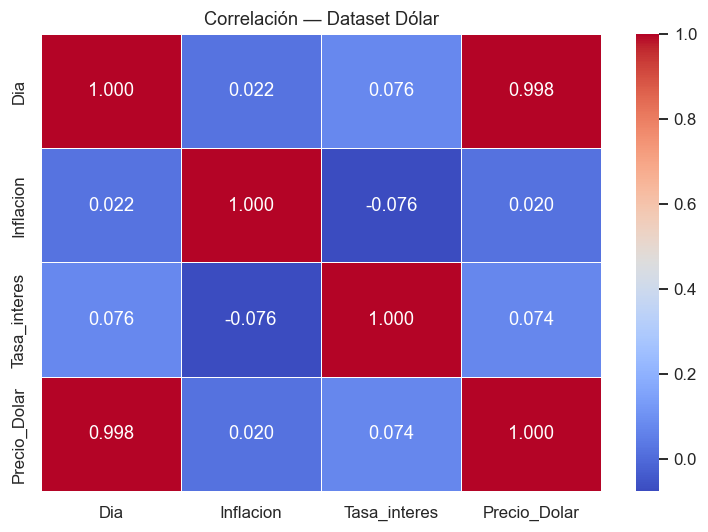

In [25]:
# ─────────────────────────────────────────────
# Fase 2 — Matriz de correlación
# Nos muestra qué tan relacionadas están las variables entre sí
# ─────────────────────────────────────────────
plt.figure(figsize=(7, 5))
sns.heatmap(df_dolar.corr(), annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlación — Dataset Dólar')
plt.tight_layout()
plt.show()

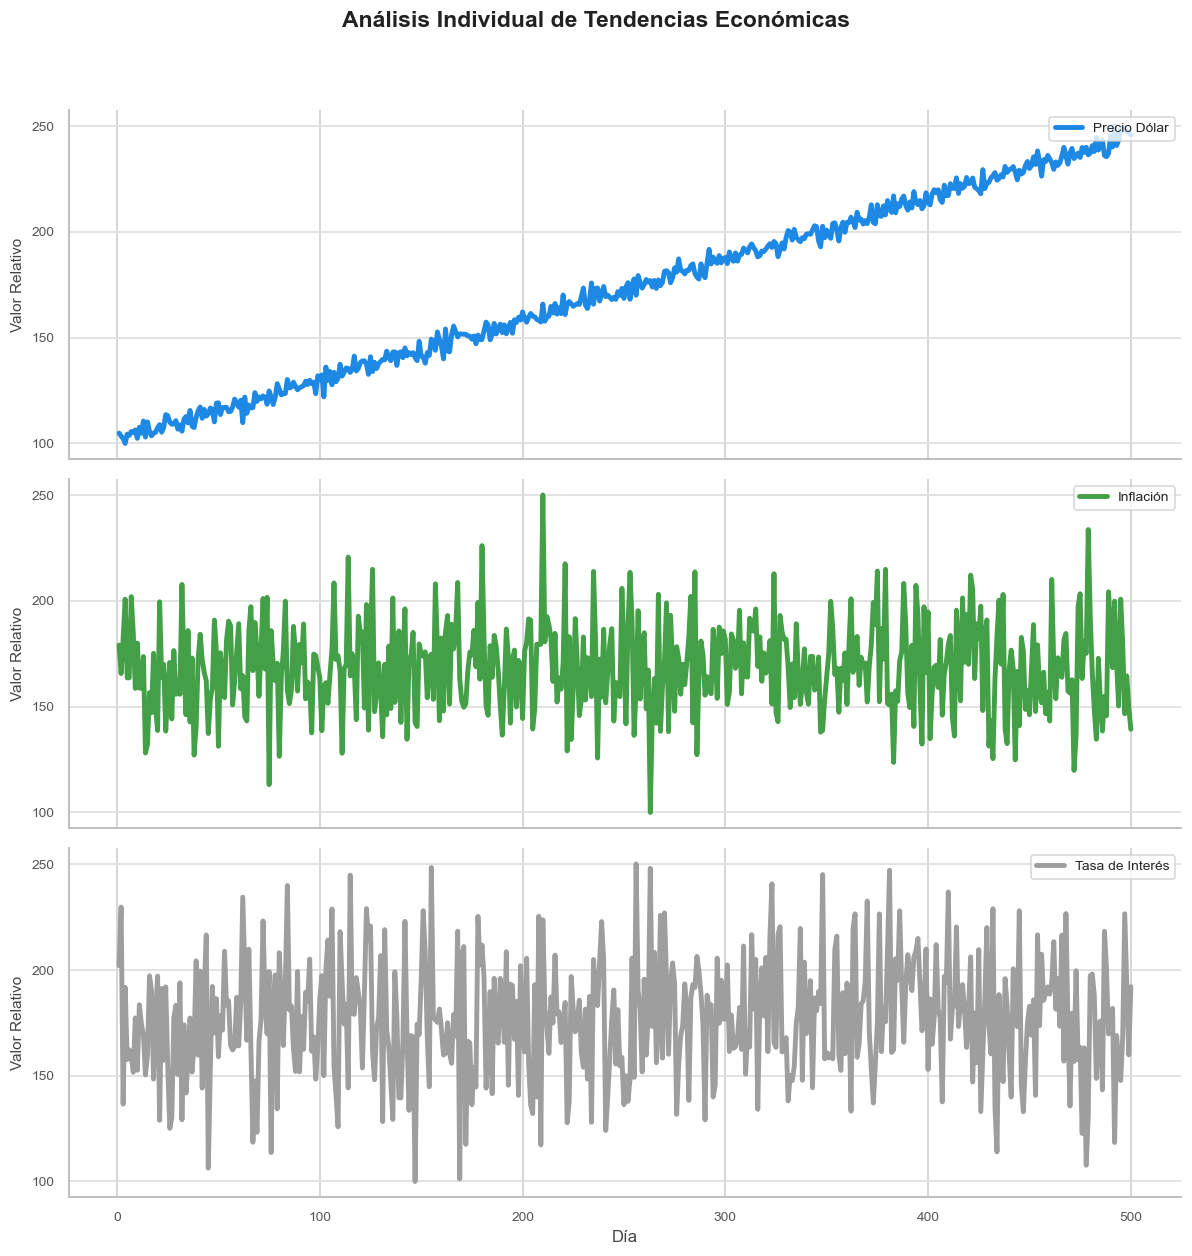

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.preprocessing import MinMaxScaler

# 1. Preparación de datos
scaler = MinMaxScaler(feature_range=(100, 250))
df_plot = df_dolar.copy()
cols = ['Precio_Dolar', 'Inflacion', 'Tasa_interes']
df_plot[cols] = scaler.fit_transform(df_plot[cols])

# 2. Configuración de la figura con 3 subplots
# sharex=True permite que todas compartan el mismo eje de tiempo abajo
fig, axs = plt.subplots(3, 1, figsize=(11, 12), sharex=True)

# Lista de configuraciones para iterar fácilmente
config = [
    ('Precio_Dolar', '#1E88E5', 'Precio Dólar'),
    ('Inflacion', '#43A047', 'Inflación'),
    ('Tasa_interes', '#9E9E9E', 'Tasa de Interés')
]

# 3. Generación de cada gráfica
for i, (col, color, label) in enumerate(config):
    ax = axs[i]
    
    # Dibujar línea
    ax.plot(df_plot['Dia'], df_plot[col], color=color, linewidth=3.2, label=label, zorder=3)
    
    # Estética estilo Economipedia
    ax.set_ylabel('Valor Relativo', fontsize=10, color='#444444')
    ax.yaxis.set_major_locator(ticker.MultipleLocator(50))
    ax.grid(True, axis='y', color='#E0E0E0', linestyle='-', linewidth=1.2, zorder=0)
    
    # Eliminar bordes innecesarios
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#BDBDBD')
    ax.spines['bottom'].set_color('#BDBDBD')
    
    # Ticks y Leyenda
    ax.tick_params(axis='both', colors='#555555', labelsize=9)
    ax.legend(loc='upper right', frameon=True, fontsize=9, edgecolor='#CCCCCC')

# Título principal y etiqueta del eje X (solo al final)
fig.suptitle('Análisis Individual de Tendencias Económicas', 
             fontsize=15, fontweight='bold', color='#212121', y=0.98)
axs[2].set_xlabel('Día', fontsize=11, color='#444444')

# Ajuste fino de espacio para evitar solapamientos
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Fase 3 — Limpieza de Datos
Aplicamos el proceso de limpieza correspondiente para asegurar la calidad de los datos antes del modelado.

In [27]:
# ─────────────────────────────────────────────
# Fase 3 — Limpieza de Datos (Avanzada)
# ─────────────────────────────────────────────
print(f'Filas iniciales: {len(df_dolar)}')

# 1. Estandarizar nombres de columnas (eliminar espacios en blanco)
df_dolar.columns = df_dolar.columns.str.strip()

# 2. Identificar y eliminar valores nulos (NaN)
nulos_iniciales = df_dolar.isnull().sum().sum()
df_dolar = df_dolar.dropna()
print(f'Valores nulos eliminados: {nulos_iniciales}')

# 3. Identificar y eliminar registros duplicados
duplicados = df_dolar.duplicated().sum()
df_dolar = df_dolar.drop_duplicates()
print(f'Duplicados eliminados: {duplicados}')

# 4. Estandarizar tipos de datos (asegurar que las columnas sean numéricas)
for col in df_dolar.columns:
    df_dolar[col] = pd.to_numeric(df_dolar[col], errors='coerce')
df_dolar = df_dolar.dropna()  # Eliminar si se generaron nuevos nulos por conversión

# 5. Detección y manejo de valores atípicos (Outliers) con el método IQR
Q1 = df_dolar.quantile(0.25)
Q3 = df_dolar.quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
condicion_outliers = ~((df_dolar < limite_inferior) | (df_dolar > limite_superior)).any(axis=1)
filas_antes_outliers = len(df_dolar)
df_dolar = df_dolar[condicion_outliers]
print(f'Valores atípicos (outliers) eliminados: {filas_antes_outliers - len(df_dolar)}')

# 6. Estandarizar el formato numérico (redondear a 4 decimales)
cols_float = df_dolar.select_dtypes(include=['float64']).columns
df_dolar[cols_float] = df_dolar[cols_float].round(4)

print(f'Filas finales tras limpieza: {len(df_dolar)}')
display(df_dolar.head())


Filas iniciales: 500
Valores nulos eliminados: 0
Duplicados eliminados: 0
Valores atípicos (outliers) eliminados: 10
Filas finales tras limpieza: 490


,Dia,Inflacion,Tasa_interes,Precio_Dolar
0,1,0.0225,5.4631,4024.8336
1,2,0.0193,5.9547,4000.5463
2,3,0.0232,4.3007,3979.6220
3,4,0.0276,5.2815,3940.3613
4,5,0.0188,4.6747,4016.9302


In [28]:
# ─────────────────────────────────────────────
# Fase 3 — DATA PREPARATION
# Separación de variables y división train/test (80/20)
# ─────────────────────────────────────────────
X1 = df_dolar[['Dia', 'Inflacion', 'Tasa_interes']]
y1 = df_dolar['Precio_Dolar']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

print(f'Train: {X1_train.shape[0]} filas | Test: {X1_test.shape[0]} filas')

Train: 392 filas | Test: 98 filas


In [29]:
# ─────────────────────────────────────────────
# Fase 4 — MODELING
# Entrenamiento del modelo de Regresión Lineal Múltiple
# Documentación: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
# ─────────────────────────────────────────────
modelo_dolar = LinearRegression()
modelo_dolar.fit(X1_train, y1_train)

# Ecuación del modelo: Precio_Dolar = b0 + b1*Dia + b2*Inflacion + b3*Tasa_interes
print('Intercepto (β₀):', round(modelo_dolar.intercept_, 4))
print('\nCoeficientes:')
for col, coef in zip(X1.columns, modelo_dolar.coef_):
    print(f'  {col:20s}: {coef:.4f}')

Intercepto (β₀): 3981.5187

Coeficientes:
  Dia                 : 4.9979
  Inflacion           : -572.5070
  Tasa_interes        : -2.2219


### Interpretación de coeficientes — Ejercicio 1

| Variable | Coeficiente | Interpretación |
|---|---|---|
| `Dia` | β₁ | Por cada día adicional, el precio del dólar **aumenta en β₁ unidades** (tendencia temporal positiva) |
| `Inflacion` | β₂ | Un aumento de 1 unidad en inflación diaria **modifica** el precio del dólar en β₂ (generalmente positivo: más inflación → dólar más caro) |
| `Tasa_interes` | β₃ | Por cada punto adicional en la tasa de interés, el precio varía en β₃ (efecto puede ser negativo: tasas altas atraen capital y aprecian la moneda local) |

> **Nota:** Los valores exactos se imprimen en la celda anterior. La magnitud relativa indica la importancia de cada variable.

In [30]:
# ─────────────────────────────────────────────
# Fase 5 — EVALUATION
# Métricas de desempeño: MSE y R²
# ─────────────────────────────────────────────
y1_pred = modelo_dolar.predict(X1_test)

mse1  = mean_squared_error(y1_test, y1_pred)
rmse1 = np.sqrt(mse1)
r2_1  = r2_score(y1_test, y1_pred)

print('═══ DESEMPEÑO DEL MODELO — DÓLAR ═══')
print(f'MSE  : {mse1:.4f}   (Error cuadrático medio: menor es mejor)')
print(f'RMSE : {rmse1:.4f}  (Error en las mismas unidades que Precio_Dolar)')
print(f'R²   : {r2_1:.4f}   (1.0 = ajuste perfecto | 0 = sin poder predictivo)')

═══ DESEMPEÑO DEL MODELO — DÓLAR ═══
MSE  : 2560.3946   (Error cuadrático medio: menor es mejor)
RMSE : 50.6003  (Error en las mismas unidades que Precio_Dolar)
R²   : 0.9959   (1.0 = ajuste perfecto | 0 = sin poder predictivo)


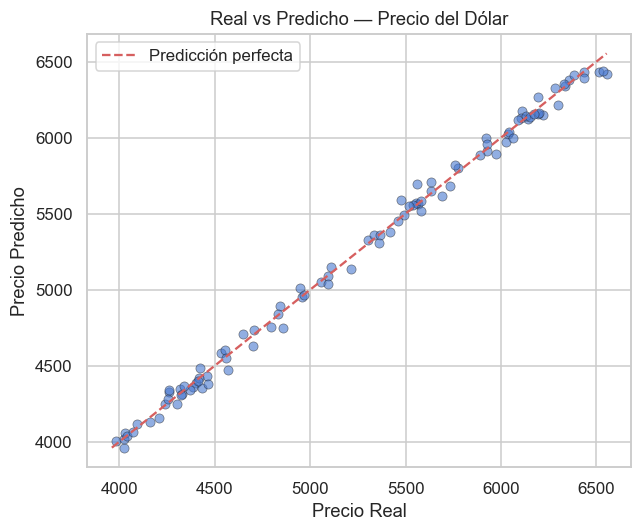

In [31]:
# ─────────────────────────────────────────────
# Fase 5 — Gráfica: Predicho vs Real
# ─────────────────────────────────────────────
plt.figure(figsize=(6, 5))
plt.scatter(y1_test, y1_pred, alpha=0.6, edgecolors='k', linewidth=0.4)
lims = [min(y1_test.min(), y1_pred.min()), max(y1_test.max(), y1_pred.max())]
plt.plot(lims, lims, 'r--', label='Predicción perfecta')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho')
plt.title('Real vs Predicho — Precio del Dólar')
plt.legend()
plt.tight_layout()
plt.show()

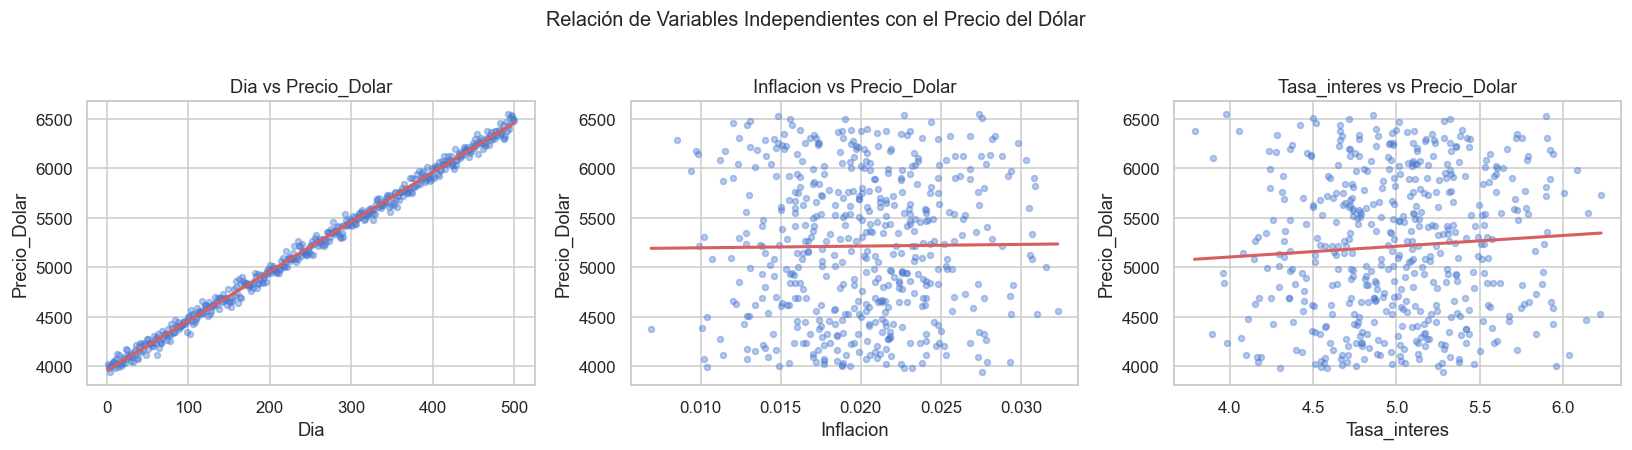

In [32]:
# ─────────────────────────────────────────────
# Fase 5 — Visualización: relación de cada predictor con Precio_Dolar
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
predictores1 = ['Dia', 'Inflacion', 'Tasa_interes']

for ax, col in zip(axes, predictores1):
    ax.scatter(df_dolar[col], df_dolar['Precio_Dolar'], alpha=0.4, s=15)
    # Línea de tendencia
    m, b = np.polyfit(df_dolar[col], df_dolar['Precio_Dolar'], 1)
    x_line = np.linspace(df_dolar[col].min(), df_dolar[col].max(), 100)
    ax.plot(x_line, m * x_line + b, 'r-', linewidth=2)
    ax.set_xlabel(col)
    ax.set_ylabel('Precio_Dolar')
    ax.set_title(f'{col} vs Precio_Dolar')

plt.suptitle('Relación de Variables Independientes con el Precio del Dólar', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [33]:
# ─────────────────────────────────────────────
# Exportación del modelo con joblib
# joblib es más eficiente que pickle para arrays NumPy grandes
# ─────────────────────────────────────────────
joblib.dump(modelo_dolar, 'modelo_dolar.pkl')
print('Modelo guardado como: modelo_dolar.pkl')

# Verificación: cargar y probar
modelo_cargado = joblib.load('modelo_dolar.pkl')
test_pred = modelo_cargado.predict([[100, 0.02, 5.0]])
print(f'Predicción de prueba (Dia=100, Inflacion=0.02, Tasa=5.0): {test_pred[0]:.2f}')

Modelo guardado como: modelo_dolar.pkl
Predicción de prueba (Dia=100, Inflacion=0.02, Tasa=5.0): 4458.75
